In [20]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt

In [21]:
root_dir = r"C:\Users\myatg\Desktop\Practical-ML-by-WAI\6_deep_learning\CNN\cats_and_dogs_filtered"

In [22]:
BATCH_SIZE  = 32
EPOCHS = 10
input_img_size = (128,128)
input_shape = (128,128,3)

In [23]:
tf_generator =  tf.keras.preprocessing.image.ImageDataGenerator(
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    rescale=1/255.0,
)

In [24]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    root_dir+"/train",
    image_size=input_img_size,
    batch_size=BATCH_SIZE,
    label_mode='binary'  # or 'categorical'
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    root_dir+"/test",
    image_size=input_img_size,
    batch_size=BATCH_SIZE,
    label_mode='binary'  # or 'categorical'
)

Found 2752 files belonging to 2 classes.
Found 248 files belonging to 2 classes.


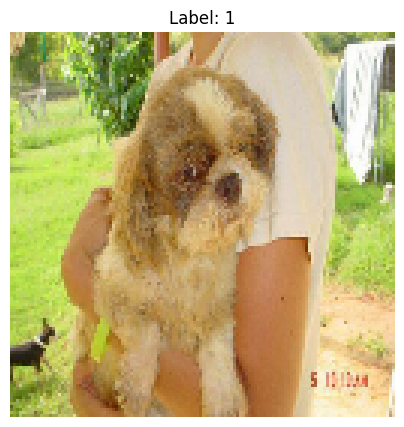

In [25]:
for images, labels in train_ds.take(1):
    plt.figure(figsize=(5,5))
    plt.imshow(images[0].numpy() / 255.)  # normalize if not already
    plt.title(f"Label: {int(labels[0])}")
    plt.axis('off')
    plt.show()
    break

In [26]:
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,Dense,Flatten,MaxPooling2D

model = Sequential([
    Conv2D(32,(3,3),activation="relu",input_shape=input_shape),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation="relu"),
    Conv2D(64,(3,3),activation="relu"),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(256,activation="relu"),
    Dense(128,activation="relu"),
    Dense(1,activation='softmax')
    
])

In [27]:
from tensorflow.keras.optimizers import Adam
model.compile(loss='binary_crossentropy',
              optimizer = Adam(),
              metrics = ['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 59, 59, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 53824)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │    13,779,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,868,545 (52.90 MB)

 Trainable params: 13,868,545 (52.90 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
history = model.fit(train_ds,epochs=EPOCHS, validation_data=val_ds,verbose=1)

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 16s 171ms/step - accuracy: 0.5023 - loss: 48.3584 - val_accuracy: 0.4597 - val_loss: 0.6935
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 170ms/step - accuracy: 0.5020 - loss: 0.6827 - val_accuracy: 0.4597 - val_loss: 0.7006
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 170ms/step - accuracy: 0.5018 - loss: 0.6569 - val_accuracy: 0.4597 - val_loss: 0.7331
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 171ms/step - accuracy: 0.4989 - loss: 0.6132 - val_accuracy: 0.4597 - val_loss: 0.9287
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 171ms/step - accuracy: 0.4993 - loss: 0.5455 - val_accuracy: 0.4597 - val_loss: 0.9655
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 171ms/step - accuracy: 0.5034 - loss: 0.4982 - val_accuracy: 0.4597 - val_loss: 1.3623
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 170ms/step - accuracy: 0.5075 - loss: 0.4312 - val_accuracy: 0.4597 - val_loss: 1.4171
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 172ms/step - accuracy: 0.5016 - loss: 0.4022 - val_acc

In [29]:
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4623 - loss: 1.8643
Validation Loss: 1.9932
Validation Accuracy: 0.4597


In [30]:
BATCH_SIZE
input_shape

(128, 128, 3)

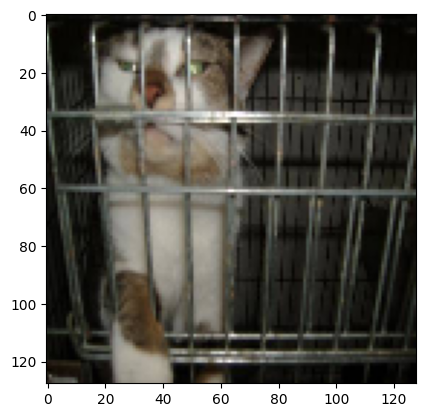

In [31]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = r"C:\Users\myatg\Desktop\Practical-ML-by-WAI\6_deep_learning\CNN\cats_and_dogs_filtered\test\cats\cat.2366.jpg"

img = image.load_img(img_path, target_size=input_img_size)
img_array = image.img_to_array(img)  # shape: (_, _, 3)
img_array = img_array / 255.0        # normalize

img_array = np.expand_dims(img_array, axis=0)  # shape: (1, _, _, 3)
plt.imshow(img_array[0])  # Display the image

In [32]:
class_names = train_ds.class_names

# Convert to dict
class_indices = {name: idx for idx, name in enumerate(class_names)}
print("Class names found:", class_indices)

Class names found: {'cats': 0, 'dogs': 1}


In [33]:
class_names

['cats', 'dogs']

In [34]:
model.predict(img_array)[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


1.0

In [35]:
prediction = model.predict(img_array)[0][0]
class_name = "dogs" if prediction > 0.5 else "cats"

print(f"Predicted class: {class_name} with confidence {prediction:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Predicted class: dogs with confidence 1.00


### Model Saving

In [36]:
import os
from dotenv import load_dotenv
load_dotenv()

ML_Summer_School_ID = os.getenv('ML_Summer_School_ID')
print("Your Sudent ID is: " + ML_Summer_School_ID)

Your Sudent ID is: ML005_Myint Myat Aung


In [37]:
model.save(f'./binary_classification/{ML_Summer_School_ID}_model.h5')

In [38]:
import json
# Save class names to a text file
with open(f'./binary_classification/{ML_Summer_School_ID}_class_indices.json', 'w') as f:
    class_names = train_ds.class_names

    # Convert to dict
    class_indices = {name: idx for idx, name in enumerate(class_names)}
    json.dump(class_indices, f)
